In [1]:
import warnings
warnings.filterwarnings("ignore")

# Creating the datasets for the experiments.

In [2]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Subset, Dataset
from torchvision import transforms
from einops import rearrange
from flwr_datasets import FederatedDataset
from flwr_datasets.partitioner import Partitioner, IidPartitioner, DirichletPartitioner, PathologicalPartitioner
from flwr_datasets.visualization import plot_label_distributions
from datasets import Dataset

The dataset creation pipeline is as follows:

* Split the training set into local training sets and proxy dataset
* Save the images already normalised
* Extract the information related to the dataset (e.g., min and max intensities)

Enter the dataset destination below:

In [3]:
OUTPUT_PATH = 'data/'
num_clients = 10
seed = 1915

os.makedirs('tmp', exist_ok=True)
os.makedirs(OUTPUT_PATH, exist_ok=True)

## Functions

In [4]:
def dataset_to_dict(dataset):
    _dict = { 'images': [], 'labels': [] }
    for batch in dataset:
        image, label = batch["image"], batch["label"]
        _dict['images'].append(image.unsqueeze(0))
        _dict['labels'].append(torch.tensor([label]))
    _dict['images'] = torch.cat(_dict['images'])
    _dict['labels'] = torch.cat(_dict['labels'])
    return _dict


def dataset_to_list(dataset):
    out = []
    for batch in dataset:
        image, label = batch["image"], batch["label"]
        out.append({"image": image, "label": label})
    return out


def crete_proxy_dataset(trainset: Dataset, proxy_fraction: float, validation_fraction: float):

        num_samples = len(trainset)
        indices = np.arange(num_samples)
        np.random.shuffle(indices)

        proxy_size = int(proxy_fraction * num_samples)
        validation_size = int(validation_fraction * num_samples)

        proxy_indices = indices[:proxy_size].tolist()
        validation_indices = indices[proxy_size:proxy_size + validation_size].tolist()
        remaining_indices = indices[proxy_size + validation_size:].tolist()

        proxy_dataset = Subset(trainset, proxy_indices)
        validation_dataset = Subset(trainset, validation_indices)
        remaining_dataset = Subset(trainset, remaining_indices)

        return proxy_dataset, validation_dataset, remaining_dataset


def create_partitions(partitioner: Partitioner, trainset: Dataset, train_transforms: transforms):
    # Assign the training dataset to the partitioner and partition it for each client
    partitioner.dataset = Dataset.from_list(trainset)
    train_partitions = []
    for i in range(partitioner.num_partitions):
        partition = partitioner.load_partition(partition_id=i).with_transform(apply_transforms(torch.tensor, "image"))
        num_samples = len(partition)
        indices = np.arange(num_samples).tolist()
        train_partitions.append( Subset(partition, indices) )
    return train_partitions


def apply_transforms(data_trasform, label):
    def transform_function(batch):
        tr =  [data_trasform(img) for img in batch[label]]
        del batch[label]
        batch["image"] = tr
        return batch
    return transform_function


def plot_partitioners(partitioners, titles, filepath):
    """
    """
    fig, ax = plt.subplots(ncols=3, figsize=(17, 5))

    for idx, (partitioner, title) in enumerate(zip(partitioners, titles)):

        _, _, df = plot_label_distributions(
            partitioner,
            label_name="label",
            plot_type="bar",
            size_unit="absolute",
            partition_id_axis="x",
            legend=True,
            verbose_labels=True,
            title="Per Partition Labels Distribution",
            cmap='twilight',
            axis=ax[idx]
        )

        ax[idx].spines[['right', 'top']].set_visible(False)
        ax[idx].set_xlabel("Clients")
        ax[idx].set_ylabel("Number of Samples")
        ax[idx].set_title(title, weight='bold')

    plt.tight_layout()
    plt.savefig(filepath, format='pdf')
    plt.show()


def visualize_proxy_and_clients_images(iidset_d, iidset_name, clients_local_sets_d, partitions_type: str):
    """
    """
    def randomload(_dict):
        img = _dict['images'][ np.random.randint(0, _dict['images'].shape[0]) ].numpy()
        img = rearrange(img, "C H W -> H W C")
        img = (img - img.min()) / (img.max() - img.min())
        return img
    
    fig, ax = plt.subplots(ncols=11, figsize=(20, 3))
    for ax_idx in range(11):
        if ax_idx == 10:
            img = randomload(iidset_d)
            title = iidset_name
        else:  # Handle client datasets
            img = randomload(clients_local_sets_d[ax_idx])
            title = f'Client-{ax_idx}'
        
        # Plot bar chart
        ax[ax_idx].imshow(img)
        ax[ax_idx].set_axis_off()
        ax[ax_idx].set_title(title)
    
    # Add overall title and adjust layout
    plt.suptitle(partitions_type, fontsize=16)
    plt.tight_layout()
    plt.show()
    
    
def do(dataset_name, 
       output_path, 
       train_transforms, 
       test_transform, 
       proxy_fraction: float, 
       label: str
    ) -> None:
    """
    """
    global seed
    fds = FederatedDataset(dataset=dataset_name, partitioners={"train": 1, "test": 1}, seed=seed)

    proxyset, validset, set_to_distribute = crete_proxy_dataset(fds.load_split("train").with_transform(apply_transforms(train_transforms, label)), proxy_fraction=proxy_fraction, validation_fraction=0.02)
    testset = fds.load_partition(0, "test").with_transform(apply_transforms(test_transform, label))
    set_to_distribute = dataset_to_list(set_to_distribute)

    # Assign the training dataset to the partitioner and partition it for each client
    validset_d = dataset_to_dict(validset)
    proxyset_d = dataset_to_dict(proxyset)
    testset_d = dataset_to_dict(testset)
    
    iid_partitioner = IidPartitioner(num_partitions=num_clients)
    clients_local_sets_iid = create_partitions(iid_partitioner, trainset=set_to_distribute, train_transforms=train_transforms)
    
    d10_partitioner = DirichletPartitioner(num_partitions=num_clients, alpha=10, partition_by="label", min_partition_size=256, seed=seed)
    clients_local_sets_wni = create_partitions(d10_partitioner, trainset=set_to_distribute, train_transforms=train_transforms)
    
    d01_partitioner = DirichletPartitioner(num_partitions=num_clients, alpha=0.1, partition_by="label", min_partition_size=256, seed=seed)
    clients_local_sets_hni = create_partitions(d01_partitioner, trainset=set_to_distribute, train_transforms=train_transforms)
     
    _dataset_name = dataset_name.split('/')[-1]
    plot_partitioners(
        [iid_partitioner, d10_partitioner, d01_partitioner], 
        ["IID", "Weak non-IID", "Strong non-IID"], 
        os.path.join(OUTPUT_PATH, f'{_dataset_name}_distributions.pdf')
    )
    
    clients_local_sets_iid_d = [ dataset_to_dict(d) for d in clients_local_sets_iid ]
    clients_local_sets_wni_d = [ dataset_to_dict(d) for d in clients_local_sets_wni ]
    clients_local_sets_hni_d = [ dataset_to_dict(d) for d in clients_local_sets_hni ]
    
    visualize_proxy_and_clients_images(proxyset_d, "proxyset", clients_local_sets_iid_d, 'IID')
    visualize_proxy_and_clients_images(testset_d,  "testset",  clients_local_sets_wni_d, 'Weak non-IID')
    visualize_proxy_and_clients_images(validset_d, "validset", clients_local_sets_hni_d, 'Strong non-IID')
    
    torch.save({
        'local_sets_iid': clients_local_sets_iid_d,
        'local_sets_wni': clients_local_sets_wni_d,
        'local_sets_hni': clients_local_sets_hni_d,
        'proxy_set': proxyset_d,
        'valid_set': validset_d,
        'test_set': testset_d,
    },  output_path)
    


## CIFAR-10

Generating test split: 100%|██████████| 10000/10000 [00:00<00:00, 425191.75 examples/s]


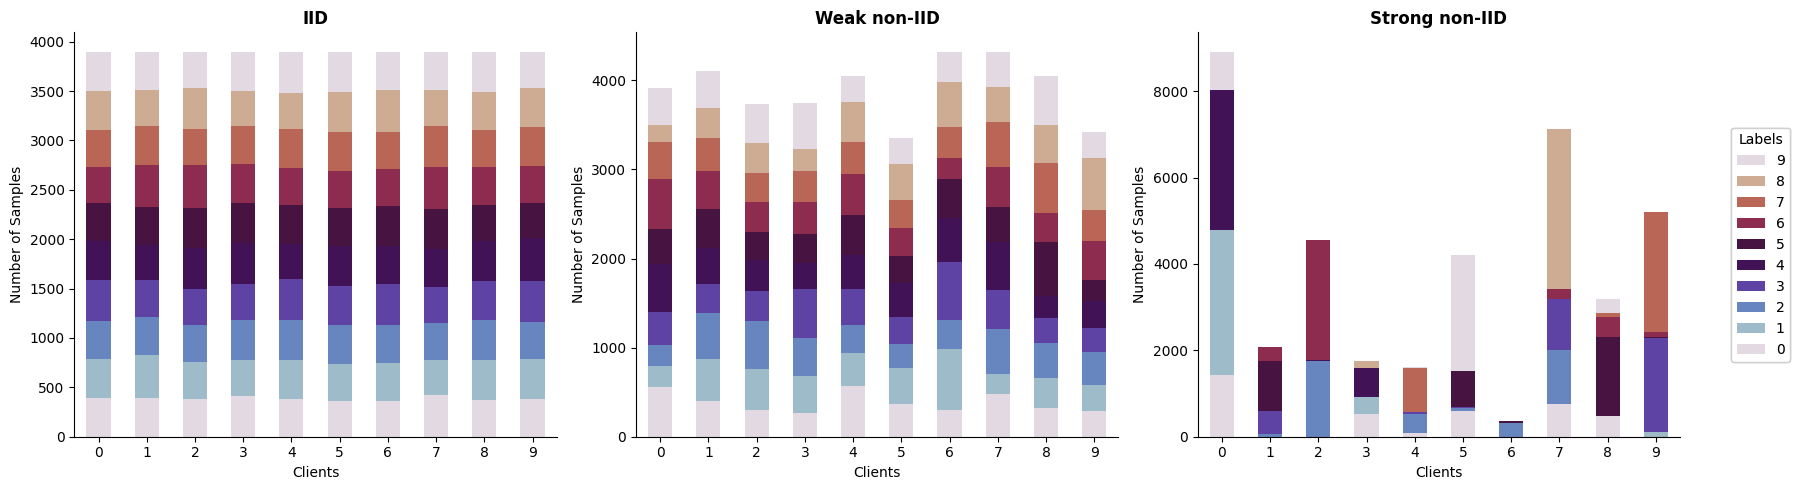

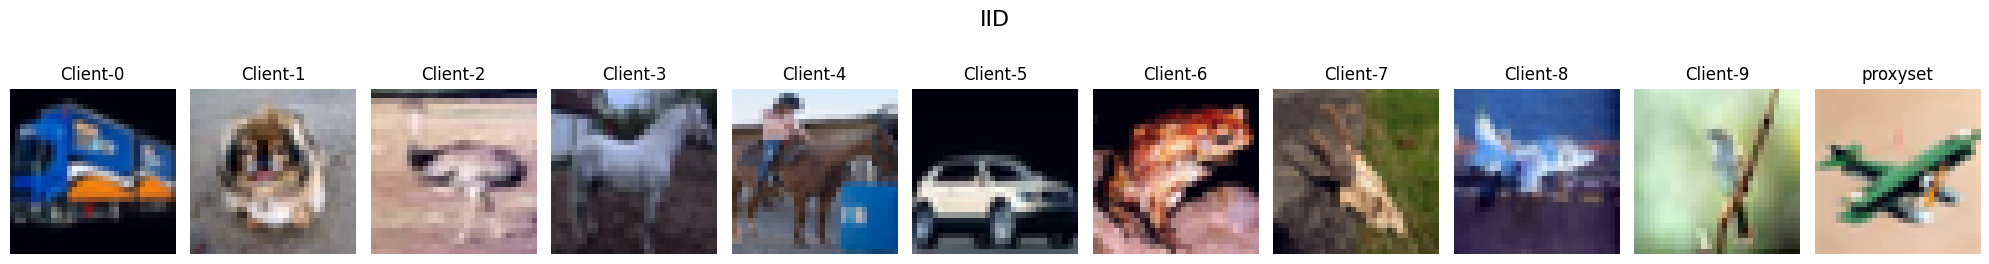

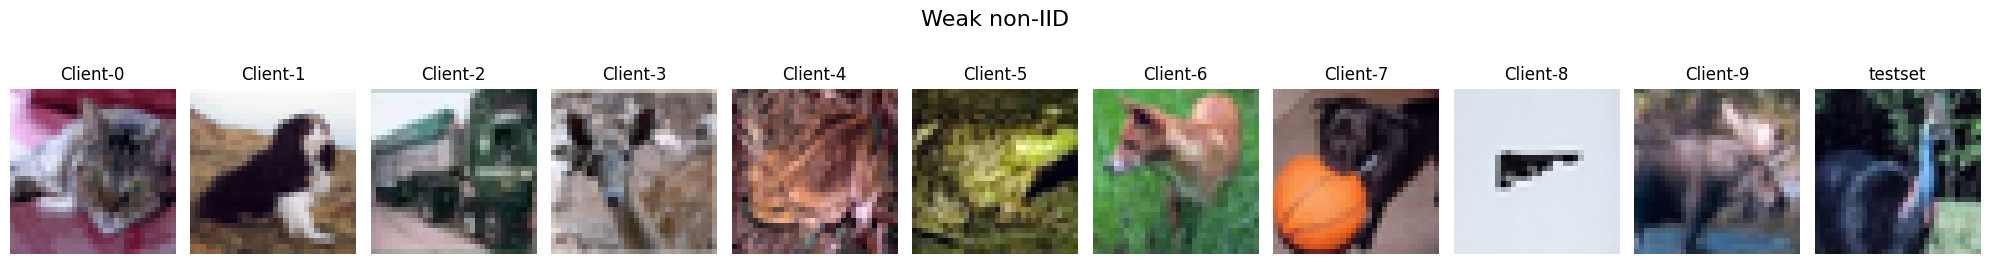

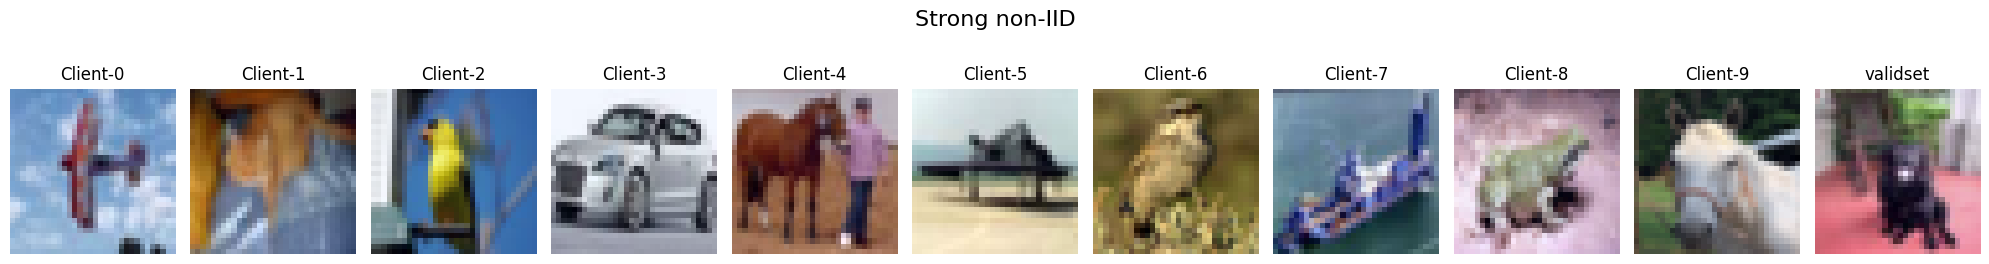

In [5]:
os.makedirs('tmp/CIFAR10', exist_ok=True)

transforms_fn = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

partitioners = do(
    dataset_name="uoft-cs/cifar10",
    output_path=os.path.join(OUTPUT_PATH, 'cifar10.pt'),
    train_transforms=transforms_fn,
    test_transform=transforms_fn, 
    proxy_fraction=0.20,
    label="img"
)

## MNIST

Generating test split: 100%|██████████| 10000/10000 [00:00<00:00, 589518.19 examples/s]


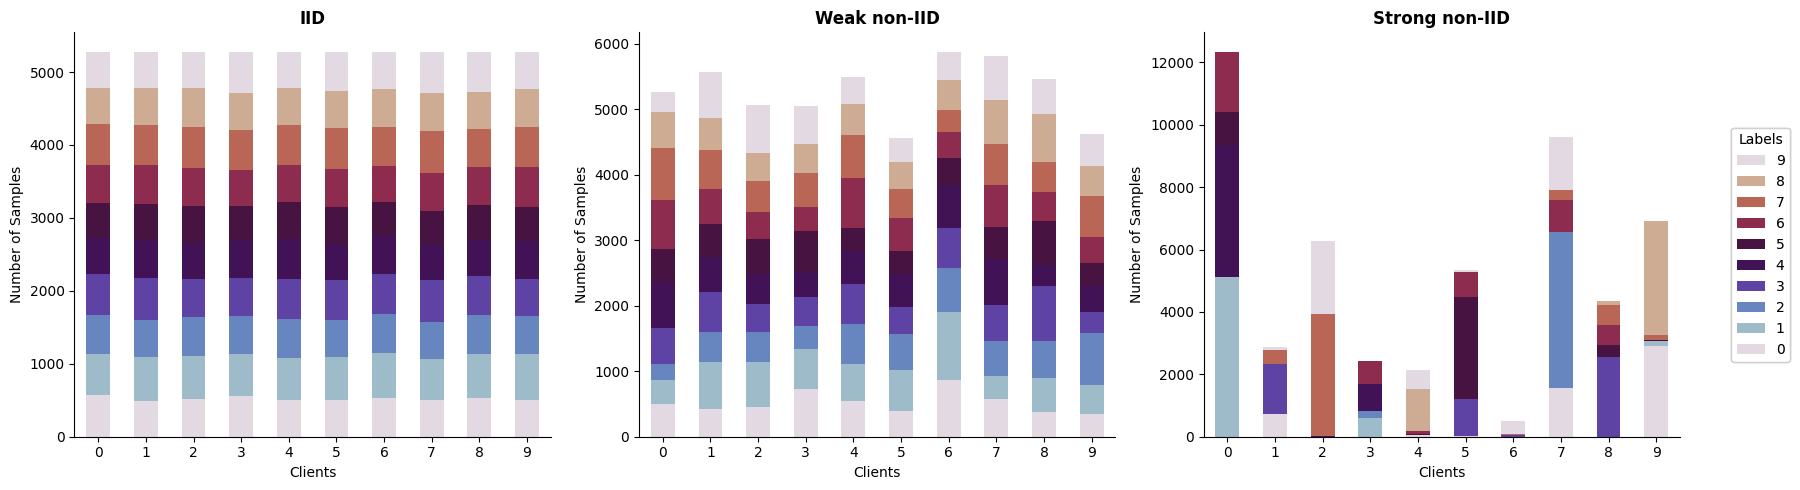

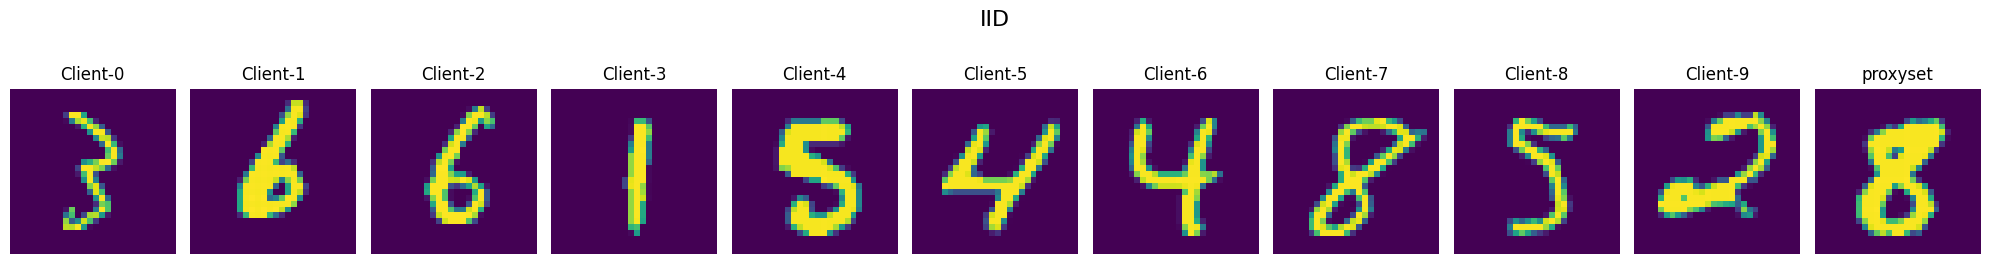

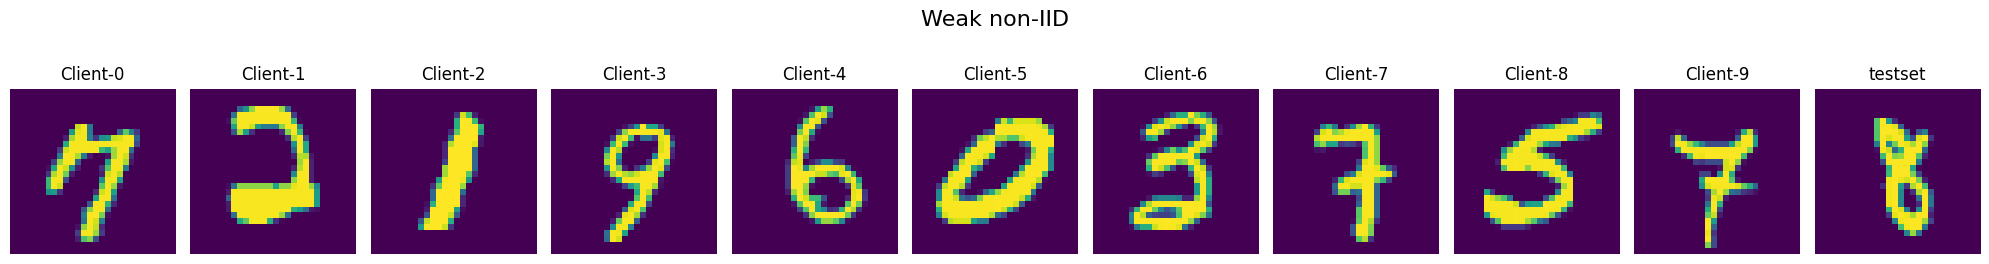

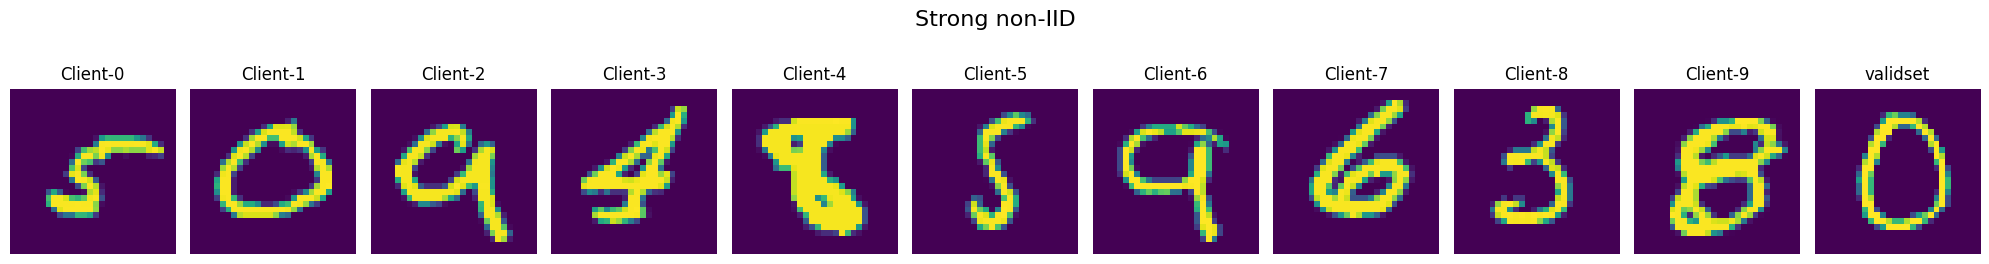

In [6]:
os.makedirs('tmp/MNIST', exist_ok=True)

transforms_fn = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

do(
    dataset_name="ylecun/mnist", 
    output_path=os.path.join(OUTPUT_PATH, 'mnist.pt'),
    train_transforms=transforms_fn, 
    test_transform=transforms_fn, 
    proxy_fraction=0.10,
    label="image"    
)

## FashionMNIST

Generating test split: 100%|██████████| 10000/10000 [00:00<00:00, 649383.64 examples/s]


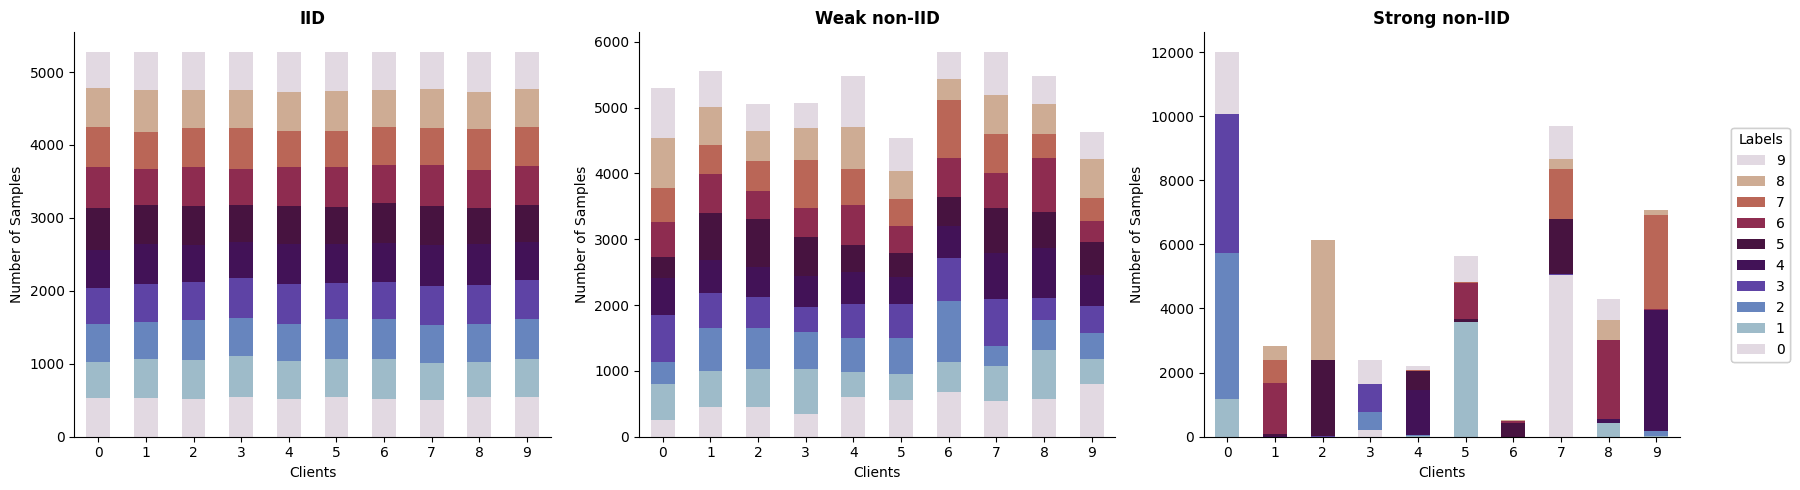

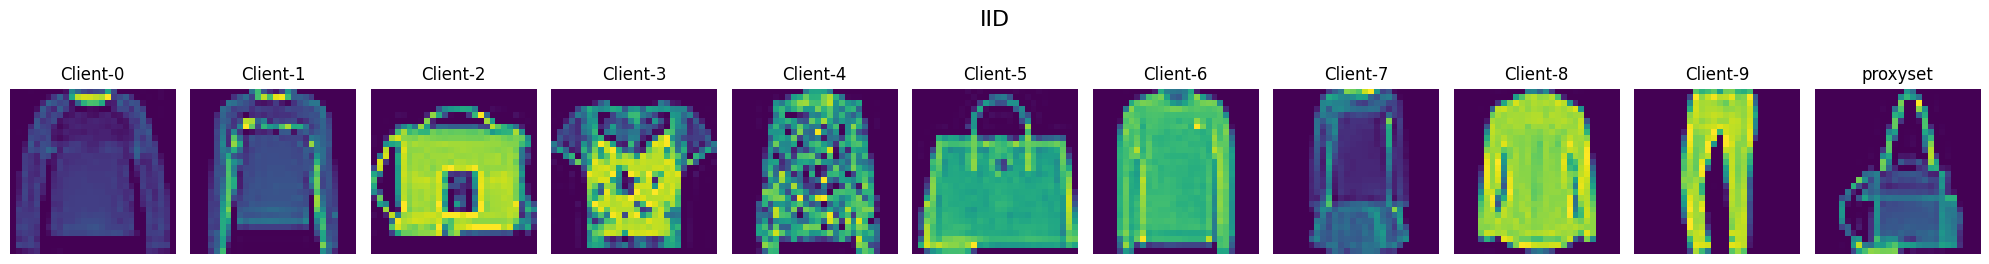

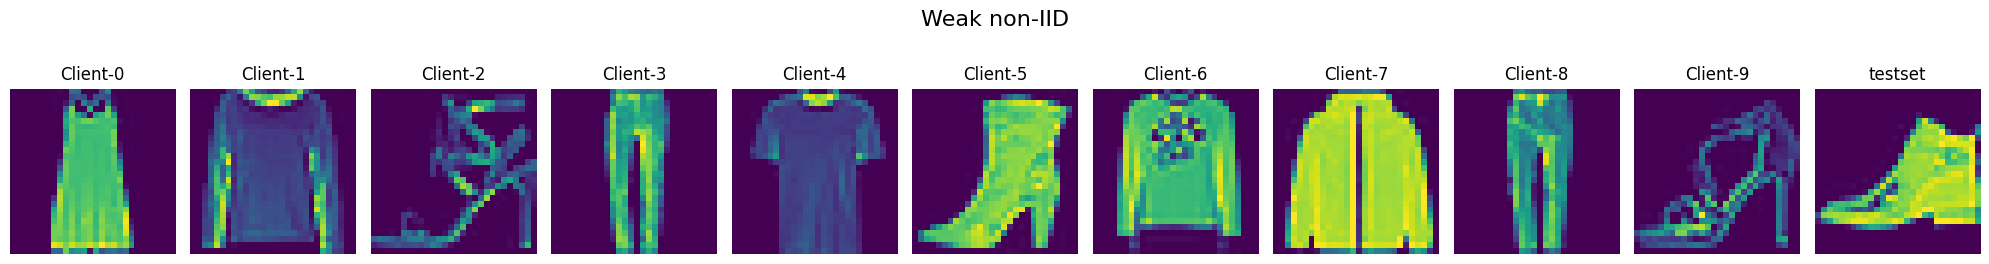

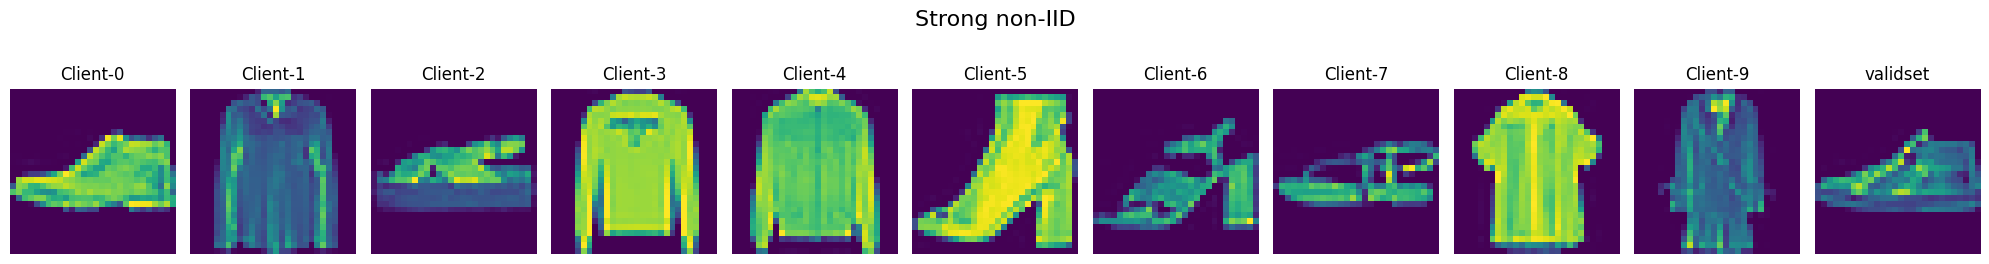

In [7]:
os.makedirs('tmp/FashionMNIST', exist_ok=True)

transforms_fn = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

do(
    dataset_name="zalando-datasets/fashion_mnist", 
    output_path=os.path.join(OUTPUT_PATH, 'fashion-mnist.pt'),
    train_transforms=transforms_fn,
    test_transform=transforms_fn,
    proxy_fraction=0.10,
    label="image"
    )
